In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import LinearLocator
import geopandas as gpd
from regionmask import mask_geopandas
import cartopy, cartopy.crs as ccrs # produce maps and other geospatial data analyses
import cartopy.feature as cfeature  # common drawing and filtering operations
import cartopy.io.shapereader as shpreader # import shapefiles
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy import stats
import pandas as pd
import rioxarray as rio
from glob import glob

In [2]:
date = []
files = sorted(glob('TIFF2024/*.tif'))
for filename in files:
    d=filename.split('_')[3]
    date.append(d)

In [3]:
date_datetime = pd.to_datetime(date)

In [4]:
date_datetime

DatetimeIndex([], dtype='datetime64[s]', freq=None)

In [26]:
for filename in files:
    d=filename.split('_')[3]
    
    tiff = rio.open_rasterio(filename).rename({'band':'timestamp'})
    
    tiff['timestamp']= pd.to_datetime(d)
    
    
    tiff.to_dataset(name = 'LST').to_netcdf(f'TIFF2024/tiff_new/netcdf_{d}.nc')

type: dimension 'timestamp' already exists as a scalar variable

In [1]:
import xarray as xr
import rioxarray as rio
import pandas as pd
import numpy as np
from glob import glob
files = sorted(glob('TIFF2024/*.tif'))
for filename in files:
    d = filename.split('_')[3]
    
    # 1. Apri il raster mantenendo il nome 'band' originale
    tiff = rio.open_rasterio(filename).sel(x = slice(12.23,13), y = slice(42.5,41.5))
    print(tiff.shape)
    # 2. Converti i dati in un nuovo array con la dimensione temporale esplicita
    time_value = pd.to_datetime(d)
    
    # 3. Crea un nuovo DataArray con la struttura corretta
    new_data = xr.DataArray(
        data=tiff.values,
        dims=('time', 'y', 'x'),
        coords={
            'time': [time_value],
            'y': tiff.y,
            'x': tiff.x
        },
        attrs=tiff.attrs
    )
    
    # 4. Crea dataset e salva
    new_dataset = new_data.to_dataset(name='LST')
    new_dataset.to_netcdf(f'TIFF2024/nc/netcdf_{d}.nc')

(1, 3117, 2400)
(1, 3117, 2400)
(1, 3116, 2400)
(1, 3115, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3115, 2399)
(1, 3116, 2400)
(1, 3115, 2399)
(1, 3115, 2399)
(1, 3115, 2399)
(1, 3115, 2399)
(1, 3115, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3116, 2399)
(1, 3115, 2399)
(1, 3115, 2399)
(1, 3116, 2399)
(1, 3115, 2399)


In [7]:
import xarray as xr
import rioxarray as rio
import pandas as pd
import numpy as np
from glob import glob
aa = xr.open_dataset(r'C:\Users\giuseppe.giugliano\CMCC Dropbox\Giuseppe Giugliano\ROCCIA_privata\TIFF2024\nc\netcdf_20240131.nc', engine = 'netcdf4').isel(y = slice(0,3115), x = slice(0,2399))
x = aa.x
y = aa.y

In [8]:
files = sorted(glob('TIFF2024/nc/*2024*.nc'))
dd = []
for filename in files:
    ds = xr.open_dataset(filename).isel(y = slice(0,3115), x = slice(0,2399))
    ds['x'] = x
    ds['y'] = y
    
    dd.append(ds)
ddd = xr.concat(dd, dim = 'time').sortby('time')

In [2]:
ddd = xr.open_dataset('TIFF2024/nc/combined.nc')

In [3]:
shapepath = gpd.read_file('C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/shape/italia/Limiti01012022/Com01012022/Com01012022_WGS84.shp').to_crs(epsg = 4326)
roma = shapepath[shapepath.COMUNE == 'Roma']
comune_bounds = roma.total_bounds

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Lista colori fornita
colori = [
    '#000080',  # Blu scuro (0)
    '#0000a0',  # Blu (2)
    '#0020c0',  # Blu intenso (4)
    '#0040e0',  # Blu chiaro (6)
    '#0060ff',  # Azzurro (8)
    '#0080ff',  # Azzurro chiaro (10)
    '#00a0ff',  # Ciano (12)
    '#00c0e0',  # Ciano chiaro (14)
    '#00e0c0',  # Verde-ciano (16)
    '#00ff80',  # Verde chiaro (18)
    '#20ff40',  # Verde (20)
    '#60ff00',  # Verde lime (22)
    '#80ff00',  # Giallo-verde (24)
    '#a0ff00',  # Giallo-verde chiaro (26)
    '#c0ff00',  # Giallo lime (28)
    '#e0ff00',  # Giallo (30)
    '#ffff00',  # Giallo puro (32)
    '#ffe000',  # Giallo-arancione (34)
    '#ffc000',  # Arancione chiaro (36)
    '#ffa000',  # Arancione (38)
    '#ff8000',  # Arancione scuro (40)
    '#ff6000',  # Rosso-arancione (42)
    '#ff4000',  # Rosso chiaro (44)
    '#ff2000',  # Rosso (46)
    '#ff0000',  # Rosso intenso (48)
    '#e00000',  # Rosso scuro (50)
    '#c00000'   # Rosso molto scuro (50+)
]

# Crea la colormap personalizzata
cmap_custom = mcolors.ListedColormap(colori)

# Valori da 0 a 50 con step 2
valori = np.arange(0, 52, 2)

In [15]:
def aggiungi_logo(fig, percorso_logo):
    if percorso_logo:
        logo = plt.imread(percorso_logo)

        # Calcola la posizione del logo
        logo_width = 0.2  # Larghezza del logo (puoi modificarla secondo le tue preferenze)
        logo_height = 0.08  # Altezza del logo (uguale all'altezza del blocco colorbar)
        logo_x = 0.6  # Allineato a destra con un piccolo margine
        logo_y = 0.12  # Stessa altezza del blocco colorbar

        # Crea un nuovo asse per il logo
        logo_ax = fig.add_axes([logo_x, logo_y, logo_width, logo_height], zorder=1000)

        # Aggiungi il logo
        logo_ax.imshow(logo)
        logo_ax.axis('off')  # Rimuovi gli assi

In [17]:
import zipfile
import os

lat = ddd['y']
lon = ddd['x']
for i in range(len(ddd.time)):
    
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    # Crea la colorbar
    norm = mcolors.BoundaryNorm(valori, cmap_custom.N)
    im = ax.pcolormesh(lon, lat, ddd.LST.isel(time=i).squeeze(), transform=ccrs.PlateCarree(), cmap=cmap_custom, norm = norm)
    roma.plot(ax=ax, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
    ax.set_extent([comune_bounds[0], comune_bounds[2], comune_bounds[1], comune_bounds[3]], crs=ccrs.PlateCarree())
    ax.set_title(str(ddd.isel(time = i).time.values)[0:10])
    gl = ax.gridlines(draw_labels=True)
    gl.right_labels = False  # Mostra le coordinate solo a sinistra e sotto
    gl.top_labels = False
    cbar = fig.colorbar(im, location = 'right', orientation='vertical',extend = 'neither', pad = 0.01)
    cbar.set_label('Temperatura Superficiale $[°C]$')
    cbar.set_ticks(valori)
    aggiungi_logo(fig, 'C:/Users/giuseppe.giugliano/Desktop/copy_dataclime_new.png')
    png_filename = f'C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_{str(ddd.isel(time = i).time.values)[0:10]}.png'
    
    
    plt.savefig(png_filename ,dpi = 300)
    
    # Crea il file ZIP con tutti i PNG
    zip_filename = f'C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_{str(ddd.isel(time = i).time.values)[0:10]}.zip'
    
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Aggiungi solo il nome del file (senza il path completo) all'interno del ZIP
        arcname = os.path.basename(png_filename)
        zipf.write(png_filename, arcname)
    
    print(f"File ZIP creato: {zip_filename}")
    plt.close()    

File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-01-15.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-01-31.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-02-16.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-03-03.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-03-19.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-04-04.zip
File ZIP creato: C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/ROCCIA_privata/TIFF2024/png/roma_zone_urbane_2024-04-20.zip
File ZIP creato: C:/Users/giuseppe.giugli

In [3]:
seas = ddd.groupby('time.season').mean(dim='time')


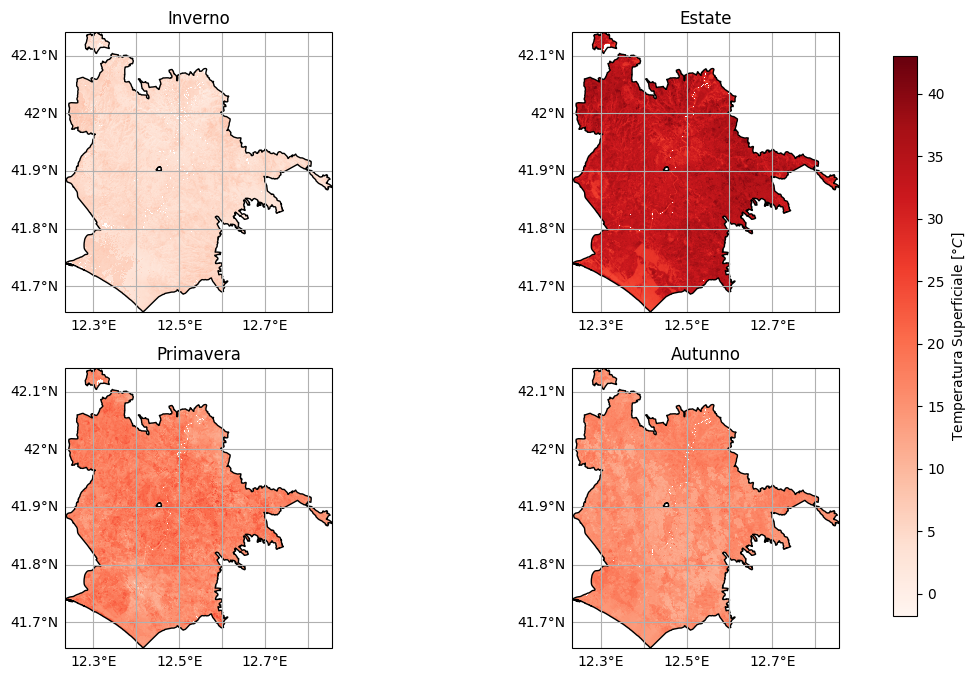

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import geopandas as gpd
shapepath = gpd.read_file('C:/Users/giuseppe.giugliano/CMCC Dropbox/Giuseppe Giugliano/shape/italia/Limiti01012022/Com01012022/Com01012022_WGS84.shp').to_crs(epsg = 4326)
roma = shapepath[shapepath.COMUNE == 'Roma']
comune_bounds = roma.total_bounds

lat = seas['y']
lon = seas['x']
seasons = seas['season'].values

# Creare la figura e gli assi
fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Determinare i limiti della colorbar comune
vmin = seas.LST.min().values
vmax = seas.LST.max().values
rename = {'DJF':'Inverno', 'JJA':'Estate', 'MAM':'Primavera', 'SON':'Autunno'}
# Creare il plot per ogni stagione
for i, season in enumerate(seasons):
    ax = axes[i]
    ax.set_title(f'{rename[season]}')
    im = ax.pcolormesh(lon, lat, seas.LST.sel(season=season).squeeze(), transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
    roma.plot(ax=ax, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
    ax.set_extent([comune_bounds[0], comune_bounds[2], comune_bounds[1], comune_bounds[3]], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True)
    gl.right_labels = False  # Mostra le coordinate solo a sinistra e sotto
    gl.top_labels = False

# Aggiungere una colorbar comune
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # Posizionare la colorbar sotto i subplot
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', pad = 0.01)
cbar.set_label('Temperatura Superficiale $[°C]$')

# plt.tight_layout(rect=[0, 0.1, 1, 1])  # Lascia spazio per la colorbar
plt.savefig('LST2024v1.png',dpi = 300)
